In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

print("Loading data...")
start = time.time()
X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')
y_train = pd.read_csv('../data/y_train.csv')['target']
y_test = pd.read_csv('../data/y_test.csv')['target']
print(f"Loaded in {time.time()-start:.0f}s")

target_encoder = joblib.load('../models/target_encoder.joblib')
class_names = target_encoder.classes_

# Retrain the model (or load if you saved it)
print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_test_pred = rf.predict(X_test)
print("Done!")

Loading data...
Loaded in 35s

Training Random Forest...
Done!


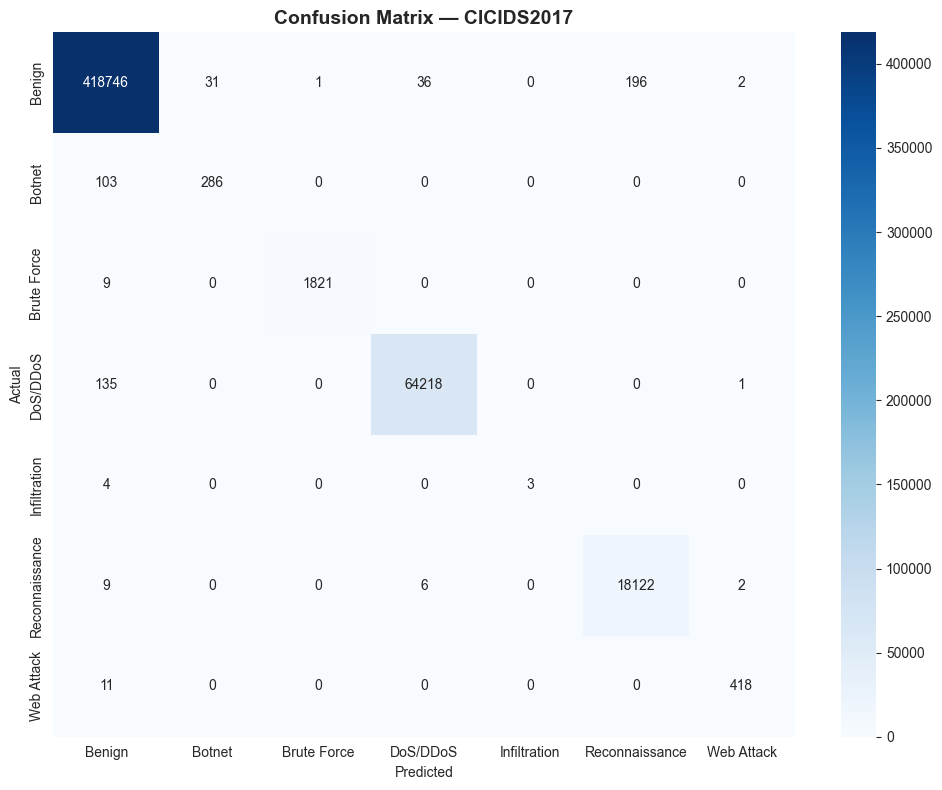

Key misclassifications (>10):
     31 actual Benign               → predicted as Botnet
     36 actual Benign               → predicted as DoS/DDoS
    196 actual Benign               → predicted as Reconnaissance
    103 actual Botnet               → predicted as Benign
    135 actual DoS/DDoS             → predicted as Benign
     11 actual Web Attack           → predicted as Benign


In [2]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix — CICIDS2017', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# Key misclassifications
print("Key misclassifications (>10):")
for i, actual in enumerate(class_names):
    for j, predicted in enumerate(class_names):
        if i != j and cm[i][j] > 10:
            print(f"  {cm[i][j]:5d} actual {actual:20s} → predicted as {predicted}")

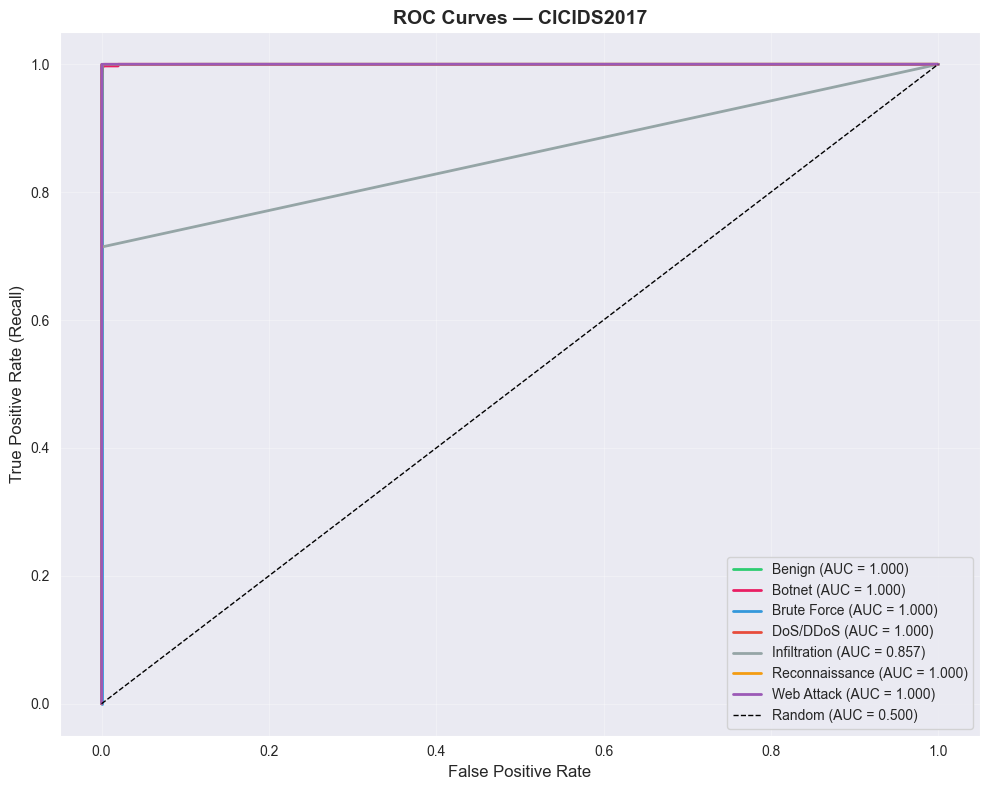

In [3]:
# ROC CURVES
y_test_proba = rf.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71', '#e91e63', '#3498db', '#e74c3c', '#95a5a6', '#f39c12', '#9b59b6']

for i, (name, color) in enumerate(zip(class_names, colors)):
    y_binary = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_binary, y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — CICIDS2017', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

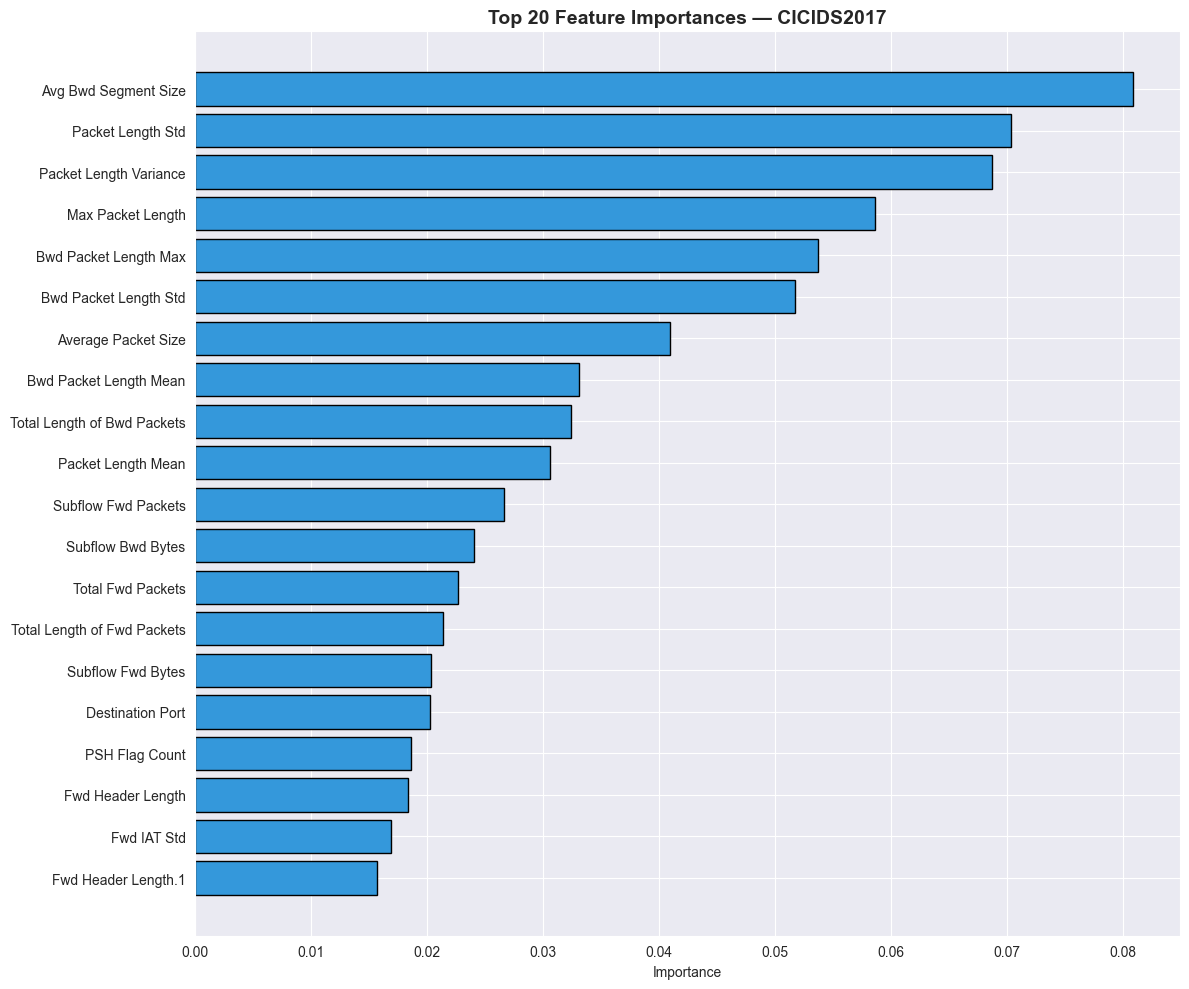

Top 10 features:
  Avg Bwd Segment Size                0.0809
  Packet Length Std                   0.0703
  Packet Length Variance              0.0687
  Max Packet Length                   0.0586
  Bwd Packet Length Max               0.0537
  Bwd Packet Length Std               0.0517
  Average Packet Size                 0.0410
  Bwd Packet Length Mean              0.0331
  Total Length of Bwd Packets         0.0324
  Packet Length Mean                  0.0306


In [4]:
# FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_20 = feature_importance.head(20)
ax.barh(range(len(top_20)), top_20['importance'], color='#3498db', edgecolor='black')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'])
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances — CICIDS2017', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 10 features:")
for _, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:35s} {row['importance']:.4f}")

BINARY CLASSIFICATION — Benign vs Attack
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    419012
      Attack       1.00      1.00      1.00     85148

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



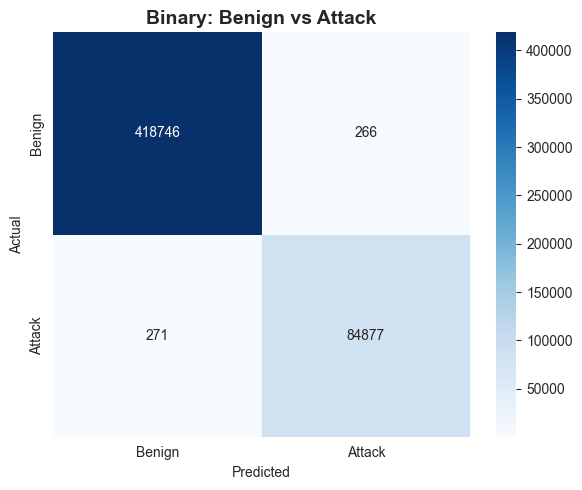

In [5]:
# BINARY — Benign vs Attack
benign_idx = list(class_names).index('Benign')
y_test_binary = (y_test != benign_idx).astype(int)
y_pred_binary = (y_test_pred != benign_idx).astype(int)

print("=" * 60)
print("BINARY CLASSIFICATION — Benign vs Attack")
print("=" * 60)
print(classification_report(y_test_binary, y_pred_binary,
                            target_names=['Benign', 'Attack']))

cm_binary = confusion_matrix(y_test_binary, y_pred_binary)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'], ax=ax)
ax.set_title('Binary: Benign vs Attack', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

In [6]:
# Save the trained model
joblib.dump(rf, '../models/random_forest.joblib')

# Save feature importance
feature_importance.to_csv('../data/feature_importance.csv', index=False)

print("PHASE 4 — FINAL SUMMARY (CICIDS2017)")
print("=" * 60)
print(f"\nModel: Random Forest (100 trees)")
print(f"Test Accuracy: 99.89%")
print(f"\nPer-class F1 scores:")
f1_scores = f1_score(y_test, y_test_pred, average=None)
for name, score in zip(class_names, f1_scores):
    status = "✓" if score > 0.9 else "~" if score > 0.7 else "✗"
    print(f"  {status} {name:20s}: {score:.3f}")
print(f"\nMacro F1: {f1_scores.mean():.3f}")
print(f"\nKnown limitations:")
print(f"  - Infiltration: only 36 samples (29 train, 7 test)")
print(f"  - Model tested within-dataset only")
print(f"  - Cross-dataset generalization likely lower")
print(f"\nPhase 4 complete!")

PHASE 4 — FINAL SUMMARY (CICIDS2017)

Model: Random Forest (100 trees)
Test Accuracy: 99.89%

Per-class F1 scores:
  ✓ Benign              : 0.999
  ~ Botnet              : 0.810
  ✓ Brute Force         : 0.997
  ✓ DoS/DDoS            : 0.999
  ✗ Infiltration        : 0.600
  ✓ Reconnaissance      : 0.994
  ✓ Web Attack          : 0.981

Macro F1: 0.912

Known limitations:
  - Infiltration: only 36 samples (29 train, 7 test)
  - Model tested within-dataset only
  - Cross-dataset generalization likely lower

Phase 4 complete!
